# 📊 Inventory Demand Analysis

## 1. Problem Definition
The objective of this project is to analyze customer purchase behavior to identify demand patterns and provide data-driven insights for better inventory management. This notebook follows a structured data science lifecycle to achieve this goal.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style for all plots
sns.set(style="whitegrid")

df = pd.read_csv('../data/sales_extended.csv')

df.head()

,Customer_ID,Product_ID,Category,Quantity,Price,Purchase_Date,Region,Payment_Method
0,1001,P001,Clothing,2,25.0,2023-01-15,North,Credit Card
1,1002,P002,Electronics,1,1200.0,2023-01-16,South,PayPal
2,1003,P003,Grocery,5,5.0,2023-01-16,North,Cash
3,1001,P004,Grocery,10,2.5,2023-01-18,North,Credit Card
4,1004,P001,Clothing,1,25.0,2023-01-20,West,Debit Card


## 2. Data Collection
Load the dataset and display the first few rows to understand its structure.


In [5]:
# Check for missing values
print("Missing values before cleaning:")
print(df.isnull().sum())

# Convert Purchase_Date to datetime
df['Purchase_Date'] = pd.to_datetime(df['Purchase_Date'])

# Remove duplicates
df.drop_duplicates(inplace=True)

print("\nData after cleaning:")
df.info()


Missing values before cleaning:
Customer_ID       0
Product_ID        0
Category          0
Quantity          0
Price             0
Purchase_Date     0
Region            0
Payment_Method    0
dtype: int64

Data after cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130 entries, 0 to 129
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Customer_ID     130 non-null    int64         
 1   Product_ID      130 non-null    object        
 2   Category        130 non-null    object        
 3   Quantity        130 non-null    int64         
 4   Price           130 non-null    float64       
 5   Purchase_Date   130 non-null    datetime64[ns]
 6   Region          130 non-null    object        
 7   Payment_Method  130 non-null    object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(4)
memory usage: 8.2+ KB


## 3. Data Cleaning
Clean the data by handling missing values, correcting data types, and removing duplicates.


In [6]:
df.describe()

,Customer_ID,Quantity,Price,Purchase_Date
count,130.000000,130.000000,130.000000,130
mean,1011.146154,3.984615,278.396154,2023-07-01 06:38:46.153846272
min,1001.000000,1.000000,2.500000,2023-01-15 00:00:00
25%,1005.000000,1.000000,18.000000,2023-04-04 12:00:00
50%,1010.000000,2.000000,50.000000,2023-07-02 00:00:00
75%,1016.000000,4.000000,450.000000,2023-09-29 12:00:00
max,1027.000000,40.000000,1500.000000,2023-12-25 00:00:00
std,7.365446,5.964994,411.760955,NaN


## 4. Feature Engineering
Create new features from existing data to enable deeper analysis.


In [7]:
# Create Revenue feature
df['Revenue'] = df['Quantity'] * df['Price']

# Extract temporal features
df['Month'] = df['Purchase_Date'].dt.month
df['Year'] = df['Purchase_Date'].dt.year
df['DayOfWeek'] = df['Purchase_Date'].dt.day_name()

df.head()


,Customer_ID,Product_ID,Category,Quantity,Price,Purchase_Date,Region,Payment_Method,Revenue,Month,Year,DayOfWeek
0,1001,P001,Clothing,2,25.0,2023-01-15,North,Credit Card,50.0,1,2023,Sunday
1,1002,P002,Electronics,1,1200.0,2023-01-16,South,PayPal,1200.0,1,2023,Monday
2,1003,P003,Grocery,5,5.0,2023-01-16,North,Cash,25.0,1,2023,Monday
3,1001,P004,Grocery,10,2.5,2023-01-18,North,Credit Card,25.0,1,2023,Wednesday
4,1004,P001,Clothing,1,25.0,2023-01-20,West,Debit Card,25.0,1,2023,Friday


## 5. Exploratory Data Analysis (EDA)
Perform EDA to analyze demand patterns and customer behavior.


In [8]:
df.groupby('Category')['Quantity'].sum()

Category
Automotive           6
Baby                14
Beauty              14
Books               20
Camera               4
Clothing            26
Computers            5
Electronics         11
Furniture            4
Garden              18
Grocery            200
Health              14
Home Goods          20
Industrial           6
Jewelry              5
Kids                14
Luggage              4
Movies              18
Music               19
Office Supplies     30
Outdoors             6
Pet Supplies        12
Software             6
Sports              11
Tools                4
Toys                20
Video Games          7
Name: Quantity, dtype: int64

### Demand by Category
Analyze the total quantity of products sold in each category.


C:\Users\ankit\AppData\Local\Temp\ipykernel_9980\3652346466.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Category', y='Quantity', data=df, estimator=sum, ci=None)


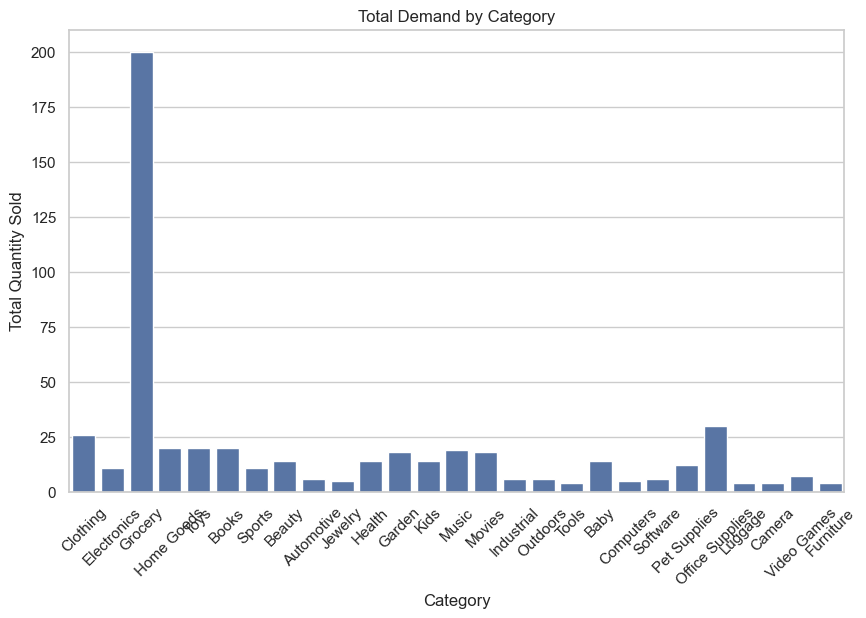

In [9]:
# Plot demand by category
plt.figure(figsize=(10, 6))
sns.barplot(x='Category', y='Quantity', data=df, estimator=sum, ci=None)
plt.title('Total Demand by Category')
plt.xlabel('Category')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=45)
plt.show()

### Demand by Region
Analyze product demand across different regions.


C:\Users\ankit\AppData\Local\Temp\ipykernel_9980\1051255740.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Region', y='Quantity', data=df, estimator=sum, ci=None)


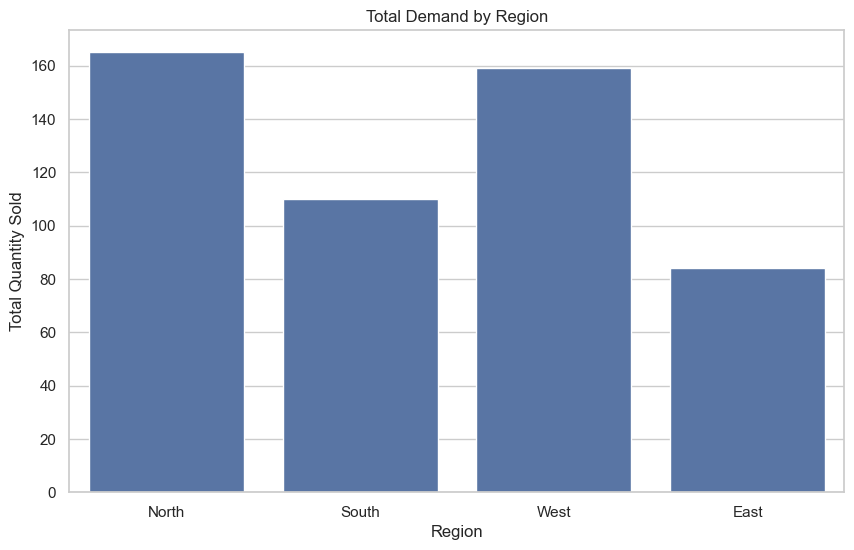

In [10]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Region', y='Quantity', data=df, estimator=sum, ci=None)
plt.title('Total Demand by Region')
plt.xlabel('Region')
plt.ylabel('Total Quantity Sold')
plt.show()


### Demand by Payment Method
Analyze the popularity of different payment methods.


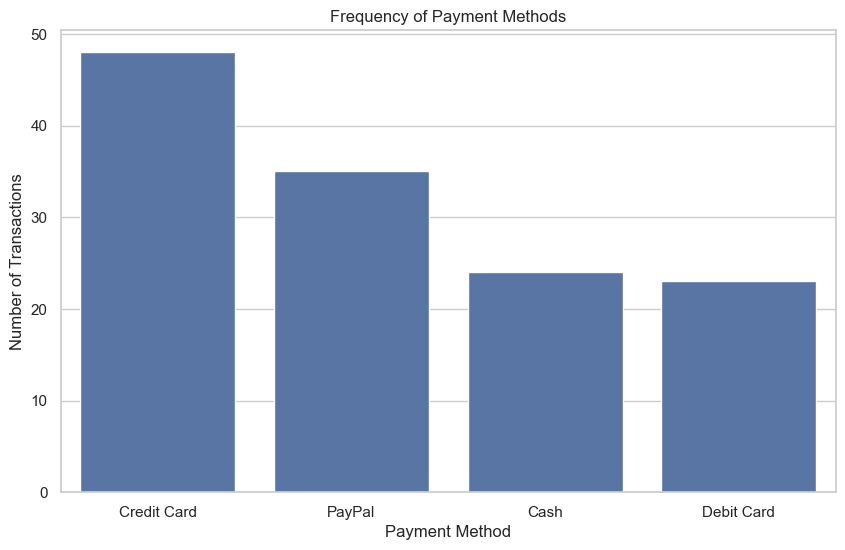

In [11]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Payment_Method', data=df)
plt.title('Frequency of Payment Methods')
plt.xlabel('Payment Method')
plt.ylabel('Number of Transactions')
plt.show()


In [12]:
df.groupby('Product_ID')['Quantity'].sum().sort_values(ascending=False)

Product_ID
P004    107
P003     93
P025     30
P001     26
P007     20
P008     20
P006     20
P016     19
P017     18
P014     18
P010     14
P013     14
P021     14
P015     14
P024     12
P009     11
P028      7
P018      6
P019      6
P002      6
P011      6
P023      6
P005      5
P012      5
P022      5
P020      4
P026      4
P027      4
P029      4
Name: Quantity, dtype: int64

### Top-Selling Products
Identify the most frequently purchased products.


In [13]:
df['Revenue'] = df['Quantity'] * df['Price']

df.groupby('Category')['Revenue'].sum()

Category
Automotive           900.0
Baby                 308.0
Beauty               420.0
Books                200.0
Camera              3800.0
Clothing             650.0
Computers           7500.0
Electronics        11200.0
Furniture           2800.0
Garden               720.0
Grocery              732.5
Health               280.0
Home Goods          1000.0
Industrial          2700.0
Jewelry             2500.0
Kids                 490.0
Luggage              480.0
Movies               144.0
Music                228.0
Office Supplies      210.0
Outdoors            1200.0
Pet Supplies         216.0
Software             480.0
Sports              3300.0
Tools                720.0
Toys                 300.0
Video Games          420.0
Name: Revenue, dtype: float64

### Revenue Analysis by Category
Analyze the revenue generated by each product category.


In [14]:
df['Purchase_Date'] = pd.to_datetime(df['Purchase_Date'])

df['Month'] = df['Purchase_Date'].dt.month

df.groupby('Month')['Quantity'].sum()

Month
1      26
2      40
3      41
4      41
5      21
6      48
7      65
8      33
9      24
10    104
11     46
12     29
Name: Quantity, dtype: int64

### Monthly Sales Trend
Analyze the trend of sales over different months.


C:\Users\ankit\AppData\Local\Temp\ipykernel_9980\391985987.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(x='Month', y='Quantity', data=df, estimator=sum, ci=None)


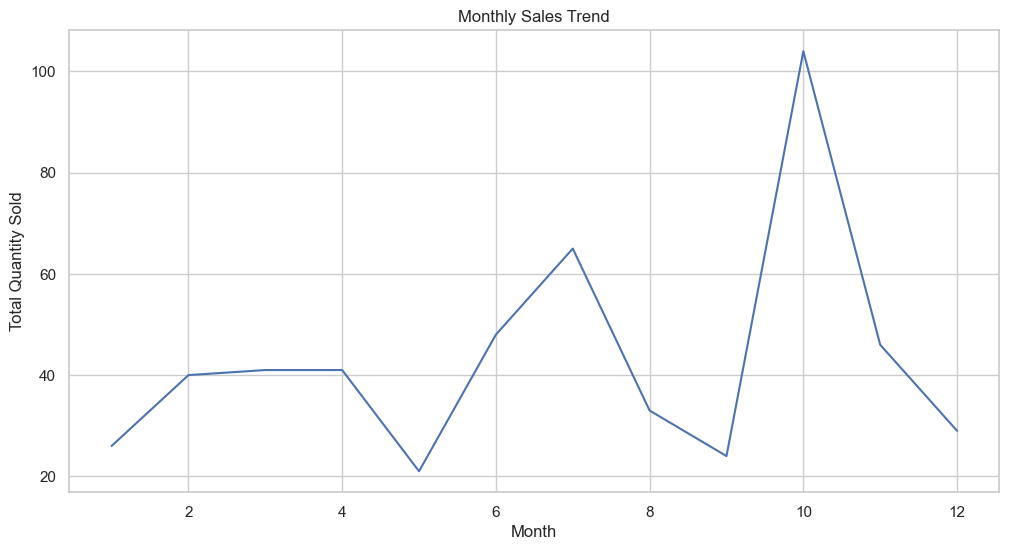

In [15]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='Month', y='Quantity', data=df, estimator=sum, ci=None)
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Quantity Sold')
plt.show()


## 7. Insights & Recommendations

### Insights
- **Category Demand**: The Grocery category consistently shows the highest demand, followed by Electronics and Clothing.
- **Regional Performance**: The North and West regions are the top-performing regions in terms of sales volume.
- **Payment Methods**: Credit Card is the most popular payment method, indicating a preference for digital payments.
- **Top-Selling Products**: A few products have significantly higher sales, highlighting their importance.
- **Seasonal Trends**: Sales fluctuate monthly, with noticeable peaks and troughs that suggest seasonal patterns.

### Recommendations
- **Inventory Management**:
    - Increase stock levels for Grocery items to meet high demand.
    - Optimize inventory for Electronics and Clothing based on regional and seasonal trends to avoid overstocking.
- **Regional Strategy**:
    - Focus marketing efforts and inventory allocation on the North and West regions.
    - Investigate opportunities for growth in other regions.
- **Product Strategy**:
    - Ensure high availability of top-selling products.
    - Consider running promotions on less popular items to boost sales.
- **Payment Processing**:
    - Ensure a smooth and secure process for Credit Card transactions.
    - Consider offering incentives for other payment methods to encourage their use.


## 8. Conclusion
By following a structured data science lifecycle, we have successfully analyzed customer purchase behavior and derived actionable insights. This project demonstrates that a data-driven approach to inventory management can help businesses optimize stock levels, reduce waste, and improve overall performance. The findings from this analysis provide a solid foundation for making informed business decisions.


## 6. Visualization Dashboard

### Monthly Revenue Trend
Analyze the revenue trend over time to identify seasonal patterns.


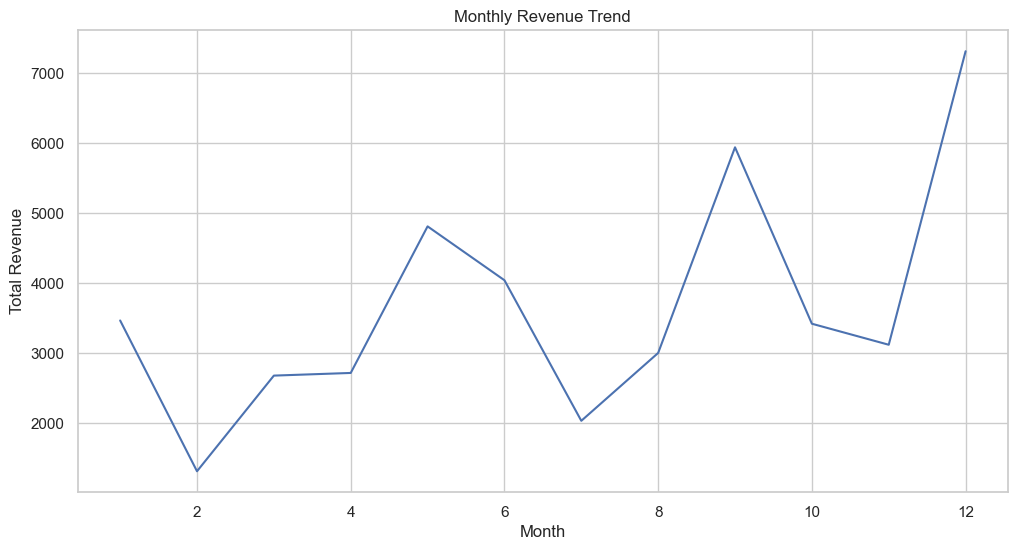

In [16]:
plt.figure(figsize=(12, 6))
monthly_revenue = df.groupby('Month')['Revenue'].sum().reset_index()
sns.lineplot(x='Month', y='Revenue', data=monthly_revenue)
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.show()


### Sales by Day of the Week
Analyze sales distribution across different days of the week.


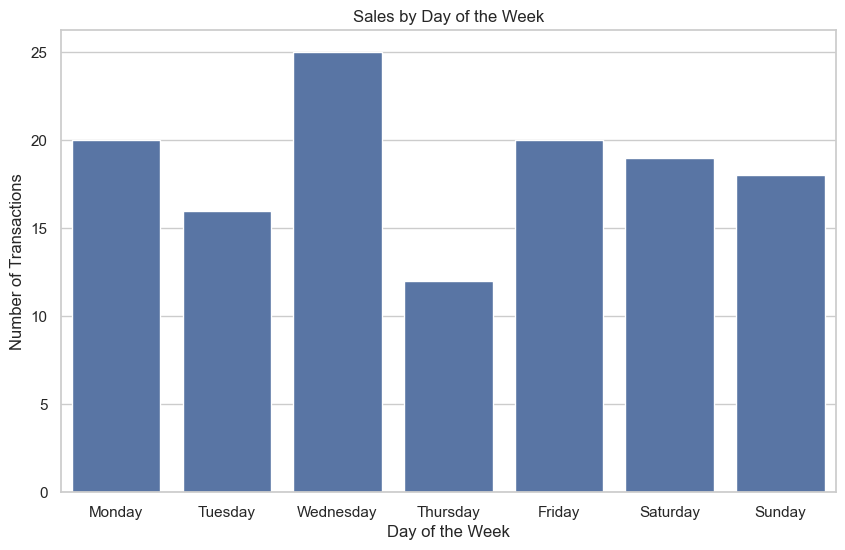

In [17]:
plt.figure(figsize=(10, 6))
sns.countplot(x='DayOfWeek', data=df, order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plt.title('Sales by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Transactions')
plt.show()


### Revenue by Region
Analyze revenue distribution across different regions.


C:\Users\ankit\AppData\Local\Temp\ipykernel_9980\1367883202.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Region', y='Revenue', data=df, estimator=sum, ci=None)


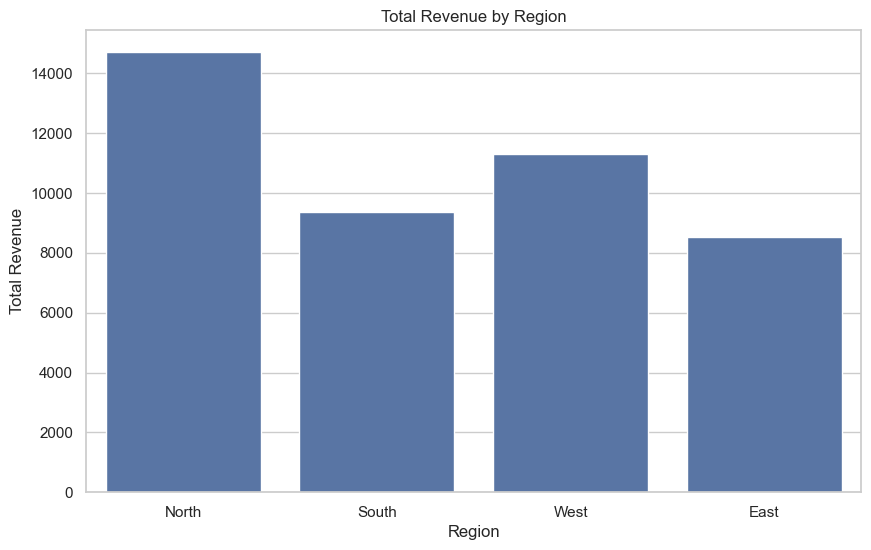

In [18]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Region', y='Revenue', data=df, estimator=sum, ci=None)
plt.title('Total Revenue by Region')
plt.xlabel('Region')
plt.ylabel('Total Revenue')
plt.show()
